# Merged Data Performance Investigation

Investigate whether adding peer university data (Lehigh, Marquette, Villanova)
improves citation prediction performance vs the AUB-only baseline.

**Baseline (AUB-only):**
- F1: 62.55% | ROC-AUC: 81.04% | Recall: 77.15% | Precision: 52.58%
- Train: ~2,605 papers (AUB 2015-2017) | Test: ~3,573 papers (AUB 2018-2020)

**Evaluation scenarios:**
- **Scenario A** — train on all-unis 2015-2017, test on **AUB-only** 2018-2020  
  *Question: does more training data improve AUB predictions?*
- **Scenario B** — train on all-unis 2015-2017, test on **all-unis** 2018-2020  
  *Question: how well does the model generalise across institutions?*

**Inputs:** `data/processed/all_unis_cleaned.pkl` (output of nb 06)

In [27]:
import sys
sys.path.append('../../')

import pandas as pd
import numpy as np
import pickle
import warnings
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
)
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
%matplotlib inline

# ── Baseline reference values ──────────────────────────────────────────────────
BASELINE = {
    'name':      'AUB-only baseline',
    'f1':        0.6255,
    'roc_auc':   0.8104,
    'recall':    0.7715,
    'precision': 0.5258,
    'threshold': 0.54,
    'n_train':   2605,
    'n_test':    3573,
}

## 1. Load Merged Data

In [28]:
data_path = Path('../../data/processed/all_unis_cleaned.pkl')

if not data_path.exists():
    raise FileNotFoundError(
        f"Merged data not found: {data_path}\n"
        "Run notebooks 04 → 05 → 06 first to generate the merged dataset."
    )

df = pd.read_pickle(data_path)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"\nRows per institution:")
print(df['institution'].value_counts().to_string())
print(f"\nYear range: {df['Year'].min()} – {df['Year'].max()}")
print(f"\nColumns: {df.columns.tolist()}")

Loaded: 39,391 rows × 69 cols

Rows per institution:
institution
AUB          14832
Lehigh        9848
Marquette     8403
Villanova     6308

Year range: 2010 – 2025

Columns: ['Title', 'Authors', 'Number of Authors', 'Scopus Author Ids', 'Year', 'Full date', 'Scopus Source title', 'Volume', 'Issue', 'Pages', 'Article number', 'ISSN', 'Source ID', 'Source type', 'Publisher', 'Language', 'SNIP (publication year)', 'SNIP percentile (publication year) *', 'CiteScore (publication year)', 'CiteScore percentile (publication year) *', 'SJR (publication year)', 'SJR percentile (publication year) *', 'Field-Weighted View Impact', 'Views', 'Citations', 'Field-Weighted Citation Impact', 'Field-Citation Average', 'Outputs in Top Citation Percentiles, per percentile', 'Field-Weighted Outputs in Top Citation Percentiles, per percentile', 'Main patent families', 'Policy citations', 'Reference', 'DOI', 'Publication type', 'Open Access', 'EID', 'PubMed ID', 'Institutions', 'Number of Institutions', 'Sc

## 2. Dataset Overview

In [29]:
# Year × institution breakdown
year_inst = (
    df.groupby(['Year', 'institution'])
    .size()
    .unstack(fill_value=0)
)
print("Papers per year per institution:")
print(year_inst.to_string())

# Citation distribution
print(f"\nCitation statistics:")
print(df['Citations'].describe().to_string())
print(f"Median: {df['Citations'].median():.0f}")

Papers per year per institution:
institution   AUB  Lehigh  Marquette  Villanova
Year                                           
2010          465     523        326        272
2011          501     540        398        277
2012          627     470        371        305
2013          705     565        408        335
2014          726     571        429        322
2015          749     626        415        343
2016          870     623        483        363
2017          926       0        512        345
2018         1062     697        603        424
2019         1129     679        623        444
2020         1382     731        644        453
2021         1332     776        671        491
2022         1233     731        656        486
2023         1043     789        631        466
2024         1045     779        656        476
2025         1037     748        577        506

Citation statistics:
count    39391.000000
mean        30.323043
std        373.796244
min          0.

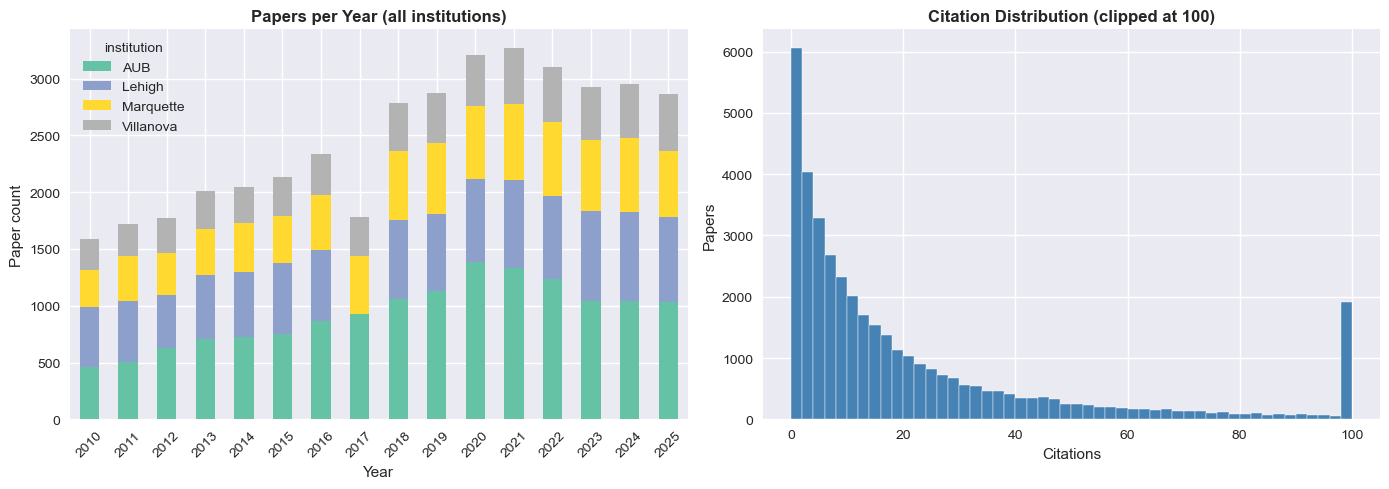

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Papers per year stacked by institution
year_inst.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title('Papers per Year (all institutions)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Paper count')
axes[0].tick_params(axis='x', rotation=45)

# Citation distribution
axes[1].hist(df['Citations'].clip(upper=100), bins=50, edgecolor='white', color='steelblue')
axes[1].set_title('Citation Distribution (clipped at 100)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Citations')
axes[1].set_ylabel('Papers')

plt.tight_layout()
plt.show()

## 3. Temporal Split

Same years as the AUB-only baseline for a fair comparison:
- **Train**: 2015 – 2017  
- **Test**: 2018 – 2020

In [31]:
TRAIN_YEARS = [2015, 2016, 2017]
TEST_YEARS  = [2018, 2019, 2020]

train_mask = df['Year'].isin(TRAIN_YEARS)
test_mask  = df['Year'].isin(TEST_YEARS)

df_train = df[train_mask].copy()
df_test  = df[test_mask].copy()

# AUB-only test subset (Scenario A)
df_test_aub = df_test[df_test['institution'] == 'AUB'].copy()

print("SPLIT SUMMARY")
print("=" * 50)
print(f"Train (2015-2017): {len(df_train):,} papers")
print(df_train['institution'].value_counts().to_string())
print(f"\nTest – all unis (2018-2020): {len(df_test):,} papers")
print(df_test['institution'].value_counts().to_string())
print(f"\nTest – AUB-only (2018-2020): {len(df_test_aub):,} papers")
print(f"\nBaseline train: ~{BASELINE['n_train']:,} | test: ~{BASELINE['n_test']:,}")

SPLIT SUMMARY
Train (2015-2017): 6,255 papers
institution
AUB          2545
Marquette    1410
Lehigh       1249
Villanova    1051

Test – all unis (2018-2020): 8,871 papers
institution
AUB          3573
Lehigh       2107
Marquette    1870
Villanova    1321

Test – AUB-only (2018-2020): 3,573 papers

Baseline train: ~2,605 | test: ~3,573


## 4. Feature Engineering

Same feature set as the AUB-only baseline:
1. **Text features** — TF-IDF on abstracts (5,000 features, bigrams; fit on train only)
2. **Venue features** — SNIP, SJR, CiteScore metrics (if columns present)
3. **Author features** — team size, collaboration indicators

### 4a. Text features (TF-IDF)

In [32]:
def preprocess_text(text):
    if pd.isna(text):
        return ""
    return str(text).lower()

abstracts_train   = df_train['Abstract'].apply(preprocess_text)
abstracts_test_all = df_test['Abstract'].apply(preprocess_text)
abstracts_test_aub = df_test_aub['Abstract'].apply(preprocess_text)

# Standard English stop words only — year tokens kept in vocabulary so the
# feature set matches the AUB-only baseline exactly.
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8,
    stop_words='english'
)

tfidf_train    = tfidf.fit_transform(abstracts_train)
tfidf_test_all = tfidf.transform(abstracts_test_all)
tfidf_test_aub = tfidf.transform(abstracts_test_aub)

feat_names = [f'tfidf_{f}' for f in tfidf.get_feature_names_out()]

text_train    = pd.DataFrame(tfidf_train.toarray(),    columns=feat_names, index=df_train.index)
text_test_all = pd.DataFrame(tfidf_test_all.toarray(), columns=feat_names, index=df_test.index)
text_test_aub = pd.DataFrame(tfidf_test_aub.toarray(), columns=feat_names, index=df_test_aub.index)

print(f"TF-IDF train:         {text_train.shape}")
print(f"TF-IDF test (all):    {text_test_all.shape}")
print(f"TF-IDF test (AUB):    {text_test_aub.shape}")

TF-IDF train:         (6255, 5000)
TF-IDF test (all):    (8871, 5000)
TF-IDF test (AUB):    (3573, 5000)


### 4b. Venue features (SNIP, SJR, CiteScore)

In [33]:
def build_venue_features(subset_df):
    """Build venue prestige features, handling missing columns gracefully."""
    def safe_float(series):
        return pd.to_numeric(series, errors='coerce')

    vf = pd.DataFrame(index=subset_df.index)

    col_map = {
        'snip':                 'SNIP (publication year)',
        'snip_percentile':      'SNIP percentile (publication year) *',
        'citescore':            'CiteScore (publication year)',
        'citescore_percentile': 'CiteScore percentile (publication year) *',
        'sjr':                  'SJR (publication year)',
        'sjr_percentile':       'SJR percentile (publication year) *',
    }

    available = {}
    for feat, col in col_map.items():
        if col in subset_df.columns:
            vf[feat] = safe_float(subset_df[col])
            available[feat] = col
        else:
            vf[feat] = np.nan  # will be filled with 0 after imputation

    # Derived features (only meaningful if underlying metrics exist)
    pct_cols = ['snip_percentile', 'citescore_percentile', 'sjr_percentile']
    vf['avg_venue_percentile'] = vf[pct_cols].mean(axis=1)
    vf['is_top_journal'] = (
        (vf['snip_percentile'] >= 90) |
        (vf['citescore_percentile'] >= 90) |
        (vf['sjr_percentile'] >= 90)
    ).astype(int)
    vf['venue_score_composite'] = (
        vf['snip'].fillna(0) * 0.33 +
        vf['citescore'].fillna(0) * 0.33 +
        vf['sjr'].fillna(0) * 0.34
    )

    # Median imputation for remaining NaNs
    for col in vf.columns:
        median_val = vf[col].median()
        if pd.isna(median_val):
            median_val = 0
        vf[col] = vf[col].fillna(median_val)

    return vf, available


venue_train, avail_cols = build_venue_features(df_train)
venue_test_all, _ = build_venue_features(df_test)
venue_test_aub, _ = build_venue_features(df_test_aub)

print(f"Venue features: {venue_train.shape[1]} features")
print(f"Available venue columns: {list(avail_cols.keys())}")
missing_venue = [k for k, v in {'snip': None, 'citescore': None, 'sjr': None}.items()
                 if k not in avail_cols]
if missing_venue:
    print(f"  NOTE: {missing_venue} not found in merged data — filled with 0")

Venue features: 9 features
Available venue columns: ['snip', 'snip_percentile', 'citescore', 'citescore_percentile', 'sjr', 'sjr_percentile']


### 4c. Author features

In [34]:
def build_author_features(subset_df):
    """Build author / collaboration features, handling missing columns."""
    af = pd.DataFrame(index=subset_df.index)

    for feat, col in [
        ('num_authors',      'Number of Authors'),
        ('num_institutions', 'Number of Institutions'),
        ('num_countries',    'Number of Countries/Regions'),
    ]:
        af[feat] = pd.to_numeric(subset_df.get(col, pd.Series(np.nan, index=subset_df.index)),
                                 errors='coerce')

    af['is_single_author']     = (af['num_authors'] == 1).astype(int)
    af['is_international_collab'] = (af['num_countries'] > 1).astype(int)
    af['is_multi_institution'] = (af['num_institutions'] > 1).astype(int)
    af['authors_per_institution'] = (
        af['num_authors'] / af['num_institutions'].replace(0, 1)
    )
    af['team_size_small']  = (af['num_authors'] <= 3).astype(int)
    af['team_size_medium'] = ((af['num_authors'] > 3) & (af['num_authors'] <= 10)).astype(int)
    af['team_size_large']  = (af['num_authors'] > 10).astype(int)

    for col in af.columns:
        af[col] = af[col].fillna(af[col].median() if not pd.isna(af[col].median()) else 0)

    return af


author_train    = build_author_features(df_train)
author_test_all = build_author_features(df_test)
author_test_aub = build_author_features(df_test_aub)

print(f"Author features: {author_train.shape[1]} features")

Author features: 10 features


In [35]:
def build_interaction_features(venue_df, author_df):
    """Interaction features between top-performing venue and author signals."""
    ix = pd.DataFrame(index=venue_df.index)
    ix['top_journal_x_intl_collab']    = venue_df['is_top_journal']      * author_df['is_international_collab']
    ix['venue_pct_x_num_authors']      = venue_df['avg_venue_percentile'] * author_df['num_authors']
    ix['venue_pct_x_num_institutions'] = venue_df['avg_venue_percentile'] * author_df['num_institutions']
    return ix


interaction_train    = build_interaction_features(venue_train, author_train)
interaction_test_all = build_interaction_features(venue_test_all, author_test_all)
interaction_test_aub = build_interaction_features(venue_test_aub, author_test_aub)

print(f"Interaction features: {interaction_train.shape[1]} features")

Interaction features: 3 features


### 4e. Metadata features (Open Access, Topic Prominence, Publication Type, Source Type)

In [36]:
def build_metadata_features(subset_df, pub_type_cols=None, source_type_cols=None):
    """Build metadata features from nb 22b: open access, topic prominence,
    publication type (one-hot), source type (one-hot).

    pub_type_cols / source_type_cols: column list from training set, used to
    align test sets to the same dummy columns.
    """
    mf = pd.DataFrame(index=subset_df.index)

    # Open Access
    mf['is_open_access'] = subset_df.get(
        'Open Access', pd.Series(np.nan, index=subset_df.index)
    ).notna().astype(int)

    # Topic Prominence
    mf['topic_prominence'] = pd.to_numeric(
        subset_df.get('Topic Prominence Percentile',
                      pd.Series(np.nan, index=subset_df.index)),
        errors='coerce'
    )
    median_tp = mf['topic_prominence'].median()
    mf['topic_prominence'] = mf['topic_prominence'].fillna(0 if pd.isna(median_tp) else median_tp)

    # Publication type (one-hot)
    pub_dummies = pd.get_dummies(
        subset_df.get('Publication type', pd.Series(dtype=str)),
        prefix='pubtype', dummy_na=False
    )
    if pub_type_cols is not None:
        pub_dummies = pub_dummies.reindex(columns=pub_type_cols, fill_value=0)

    # Source type (one-hot)
    src_dummies = pd.get_dummies(
        subset_df.get('Source type', pd.Series(dtype=str)),
        prefix='sourcetype', dummy_na=False
    )
    if source_type_cols is not None:
        src_dummies = src_dummies.reindex(columns=source_type_cols, fill_value=0)

    mf = pd.concat([mf, pub_dummies, src_dummies], axis=1)
    return mf, list(pub_dummies.columns), list(src_dummies.columns)


meta_train, pub_type_cols, source_type_cols = build_metadata_features(df_train)
meta_test_all, _, _ = build_metadata_features(df_test,    pub_type_cols, source_type_cols)
meta_test_aub, _, _ = build_metadata_features(df_test_aub, pub_type_cols, source_type_cols)

print(f"Metadata features: {meta_train.shape[1]} features")
print(f"  is_open_access:    1")
print(f"  topic_prominence:  1")
print(f"  pubtype dummies:   {len(pub_type_cols)}")
print(f"  sourcetype dummies:{len(source_type_cols)}")

Metadata features: 8 features
  is_open_access:    1
  topic_prominence:  1
  pubtype dummies:   2
  sourcetype dummies:4


### 4f. Temporal features (years since publication)

In [37]:
# Use approximate data-collection year as reference so all 2015-2020 papers
# get a positive, spread-out value (4–9 years). Using max(TRAIN_YEARS)=2017
# would clip test papers (2018-2020) to 0, destroying the signal.
REFERENCE_YEAR = 2024

def build_temporal_features(subset_df):
    """Citation-exposure proxy: how many years a paper had to accumulate cites."""
    tf = pd.DataFrame(index=subset_df.index)
    pub_year = pd.to_numeric(subset_df.get('Year', pd.Series(REFERENCE_YEAR, index=subset_df.index)),
                             errors='coerce').fillna(REFERENCE_YEAR)
    tf['pub_year']               = pub_year
    # No clip — with REFERENCE_YEAR=2024, all 2015-2020 papers are in [4, 9] range
    tf['years_since_publication'] = REFERENCE_YEAR - pub_year
    return tf


temporal_train    = build_temporal_features(df_train)
temporal_test_all = build_temporal_features(df_test)
temporal_test_aub = build_temporal_features(df_test_aub)

print(f"Temporal features: {temporal_train.shape[1]} features")
print(temporal_train.describe().T[['mean','min','max']])

Temporal features: 2 features
                                mean     min     max
pub_year                 2015.944045  2015.0  2017.0
years_since_publication     8.055955     7.0     9.0


### 4d. Combine feature matrices

In [38]:
import re

X_train     = pd.concat([text_train, venue_train, author_train, meta_train, interaction_train, temporal_train], axis=1)
X_test_all  = pd.concat([text_test_all, venue_test_all, author_test_all, meta_test_all, interaction_test_all, temporal_test_all], axis=1)
X_test_aub  = pd.concat([text_test_aub, venue_test_aub, author_test_aub, meta_test_aub, interaction_test_aub, temporal_test_aub], axis=1)

# Drop year-token TF-IDF columns (tfidf_2015, tfidf_2016, …).
# These appear in abstracts when citing related work by year and correlate
# with training-window years but shift distributionally in test papers.
year_token_cols = [c for c in X_train.columns if re.match(r'tfidf_\d{4}$', c)]
X_train    = X_train.drop(columns=year_token_cols)
X_test_all = X_test_all.drop(columns=year_token_cols, errors='ignore')
X_test_aub = X_test_aub.drop(columns=year_token_cols, errors='ignore')
print(f"Dropped year-token TF-IDF columns ({len(year_token_cols)}): {year_token_cols}")

print(f"\nFeature matrix – train:       {X_train.shape}")
print(f"Feature matrix – test (all):  {X_test_all.shape}")
print(f"Feature matrix – test (AUB):  {X_test_aub.shape}")
print(f"\nFeature breakdown:")
print(f"  TF-IDF:        {text_train.shape[1] - len(year_token_cols)}")
print(f"  Venue:         {venue_train.shape[1]}")
print(f"  Author:        {author_train.shape[1]}")
print(f"  Metadata:      {meta_train.shape[1]}")
print(f"  Interactions:  {interaction_train.shape[1]}")
print(f"  Temporal:      {temporal_train.shape[1]}")
print(f"  Total:         {X_train.shape[1]}")

Dropped year-token TF-IDF columns (19): ['tfidf_0001', 'tfidf_1000', 'tfidf_1990', 'tfidf_2000', 'tfidf_2002', 'tfidf_2004', 'tfidf_2005', 'tfidf_2006', 'tfidf_2007', 'tfidf_2008', 'tfidf_2009', 'tfidf_2010', 'tfidf_2011', 'tfidf_2012', 'tfidf_2013', 'tfidf_2014', 'tfidf_2015', 'tfidf_2016', 'tfidf_2017']

Feature matrix – train:       (6255, 5013)
Feature matrix – test (all):  (8871, 5013)
Feature matrix – test (AUB):  (3573, 5013)

Feature breakdown:
  TF-IDF:        4981
  Venue:         9
  Author:        10
  Metadata:      8
  Interactions:  3
  Temporal:      2
  Total:         5013


## 5. Build Targets

In [39]:
# ── Citation thresholds ────────────────────────────────────────────────────────
# y_train  : merged 75th pct → single consistent threshold across all
#            institutions, guarantees ~25% positive class.
# y_test_* : AUB-only 75th pct for apples-to-apples comparison with the
#            AUB-only baseline.

merged_threshold = df_train['Citations'].quantile(0.75)
aub_threshold    = df_train.loc[df_train['institution'] == 'AUB', 'Citations'].quantile(0.75)

y_train    = (df_train['Citations']     >= merged_threshold).astype(int)
y_test_aub = (df_test_aub['Citations'] >= aub_threshold).astype(int)
y_test_all = (df_test['Citations']     >= merged_threshold).astype(int)

print(f"Merged threshold  (75th pct, all-unis train): {merged_threshold:.0f} citations")
print(f"AUB threshold     (75th pct, AUB train only): {aub_threshold:.0f} citations")
print(f"\nTrain high-impact:         {y_train.mean()*100:.1f}%  ({y_train.sum():,}/{len(y_train):,})")
print(f"Test AUB high-impact:      {y_test_aub.mean()*100:.1f}%  ({y_test_aub.sum():,}/{len(y_test_aub):,})")
print(f"Test all-unis high-impact: {y_test_all.mean()*100:.1f}%  ({y_test_all.sum():,}/{len(y_test_all):,})")

Merged threshold  (75th pct, all-unis train): 39 citations
AUB threshold     (75th pct, AUB train only): 38 citations

Train high-impact:         25.5%  (1,595/6,255)
Test AUB high-impact:      19.3%  (689/3,573)
Test all-unis high-impact: 19.2%  (1,701/8,871)


## 6. Train Models — Logistic Regression, Random Forest, LightGBM

In [40]:
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
    ),
}

trained_models   = {}
proba_aub_dict   = {}
proba_all_dict   = {}

for name, clf in MODELS.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
    trained_models[name]  = clf
    proba_aub_dict[name]  = clf.predict_proba(X_test_aub)[:, 1]
    proba_all_dict[name]  = clf.predict_proba(X_test_all)[:, 1]
    print(f"  done.")

print("\nAll models trained.")

Training Logistic Regression...
  done.
Training Random Forest...
  done.
Training LightGBM...
  done.

All models trained.


## 7. Threshold Optimisation

In [41]:
def find_optimal_threshold(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.90, 0.01)
    f1s = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(f1s))
    return thresholds[best_idx], f1s[best_idx], f1s

thresholds = np.arange(0.10, 0.90, 0.01)

opt_aub = {}  # {model_name: (threshold, f1, f1s)}
opt_all = {}

for name in MODELS:
    opt_aub[name] = find_optimal_threshold(y_test_aub, proba_aub_dict[name], thresholds)
    opt_all[name] = find_optimal_threshold(y_test_all, proba_all_dict[name], thresholds)
    print(f"{name:<22}  AUB: t={opt_aub[name][0]:.2f} F1={opt_aub[name][1]*100:.2f}%"
          f"  |  All: t={opt_all[name][0]:.2f} F1={opt_all[name][1]*100:.2f}%")

Logistic Regression     AUB: t=0.55 F1=52.41%  |  All: t=0.57 F1=52.74%
Random Forest           AUB: t=0.55 F1=51.64%  |  All: t=0.53 F1=51.45%
LightGBM                AUB: t=0.31 F1=54.53%  |  All: t=0.31 F1=52.52%


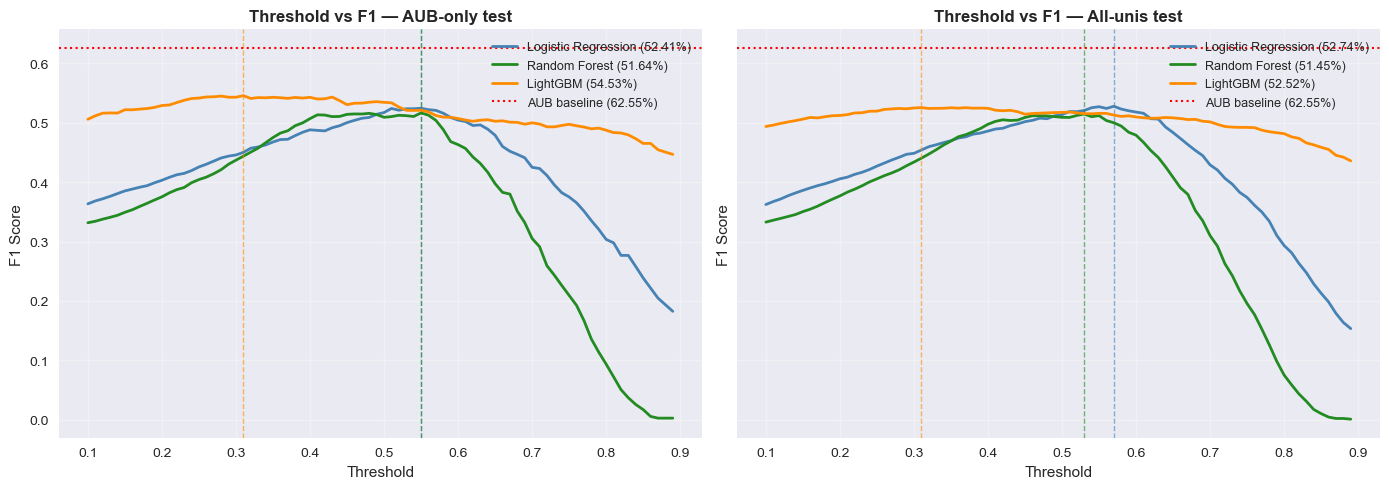

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = ['steelblue', 'forestgreen', 'darkorange']

for ax, opt_dict, proba_dict, y_true, label in [
    (axes[0], opt_aub, proba_aub_dict, y_test_aub, 'AUB-only test'),
    (axes[1], opt_all, proba_all_dict, y_test_all, 'All-unis test'),
]:
    for (name, (opt_t, opt_f1, f1s)), color in zip(opt_dict.items(), colors):
        ax.plot(thresholds, f1s, linewidth=2, label=f'{name} ({opt_f1*100:.2f}%)', color=color)
        ax.axvline(opt_t, color=color, linestyle='--', linewidth=1, alpha=0.6)
    ax.axhline(BASELINE['f1'], color='red', linestyle=':', linewidth=1.5,
               label=f'AUB baseline ({BASELINE["f1"]*100:.2f}%)')
    ax.set_title(f'Threshold vs F1 — {label}', fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('F1 Score')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
figures_dir = Path('../../reports/figures')
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / 'merged_data_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Full Metrics at Optimal Threshold

In [43]:
def compute_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'f1':        f1_score(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, y_proba),
        'recall':    recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'threshold': threshold,
        'n_test':    len(y_true),
        'n_train':   len(y_train),
    }

metrics_aub = {}
metrics_all = {}

for name in MODELS:
    metrics_aub[name] = compute_metrics(y_test_aub, proba_aub_dict[name], opt_aub[name][0])
    metrics_all[name] = compute_metrics(y_test_all, proba_all_dict[name], opt_all[name][0])

# Display comparison table
print("AUB-ONLY TEST (Scenario A)")
print("=" * 80)
print(f"{'Model':<25} {'F1':>8} {'ROC-AUC':>9} {'Recall':>8} {'Precision':>10} {'Δ F1':>8}")
print("-" * 80)
print(f"{'AUB-only baseline':<25} {BASELINE['f1']*100:>7.2f}% {BASELINE['roc_auc']*100:>8.2f}% "
      f"{BASELINE['recall']*100:>7.2f}% {BASELINE['precision']*100:>9.2f}%  {'—':>7}")
for name in MODELS:
    m = metrics_aub[name]
    delta = (m['f1'] - BASELINE['f1']) * 100
    print(f"  {name:<23} {m['f1']*100:>7.2f}% {m['roc_auc']*100:>8.2f}% "
          f"{m['recall']*100:>7.2f}% {m['precision']*100:>9.2f}% {delta:>+7.2f}pp")
print("=" * 80)

AUB-ONLY TEST (Scenario A)
Model                           F1   ROC-AUC   Recall  Precision     Δ F1
--------------------------------------------------------------------------------
AUB-only baseline           62.55%    81.04%   77.15%     52.58%        —
  Logistic Regression       52.41%    80.47%   60.67%     46.14%  -10.14pp
  Random Forest             51.64%    80.71%   52.69%     50.63%  -10.91pp
  LightGBM                  54.53%    81.46%   67.63%     45.69%   -8.02pp


## 9. Scenario A — AUB-only Test: Δ vs Baseline

In [44]:
print("SCENARIO A — Impact of merged training data per model (AUB test)")
print("=" * 70)
print(f"{'Model':<25} {'Baseline F1':>12} {'Merged F1':>11} {'Δ F1':>9} {'Δ ROC-AUC':>11}")
print("-" * 70)
for name in MODELS:
    m = metrics_aub[name]
    df1  = (m['f1']      - BASELINE['f1'])      * 100
    dauc = (m['roc_auc'] - BASELINE['roc_auc']) * 100
    marker = " ◄ BEST" if m['f1'] == max(metrics_aub[n]['f1'] for n in MODELS) else ""
    print(f"  {name:<23} {BASELINE['f1']*100:>11.2f}% {m['f1']*100:>10.2f}% {df1:>+8.2f}pp {dauc:>+10.2f}pp{marker}")
print("-" * 70)
print(f"Train size: {BASELINE['n_train']:,} → {len(y_train):,} papers (+{len(y_train)-BASELINE['n_train']:,})")

SCENARIO A — Impact of merged training data per model (AUB test)
Model                      Baseline F1   Merged F1      Δ F1   Δ ROC-AUC
----------------------------------------------------------------------
  Logistic Regression           62.55%      52.41%   -10.14pp      -0.57pp
  Random Forest                 62.55%      51.64%   -10.91pp      -0.33pp
  LightGBM                      62.55%      54.53%    -8.02pp      +0.42pp ◄ BEST
----------------------------------------------------------------------
Train size: 2,605 → 6,255 papers (+3,650)


## 10. Scenario B — Cross-institution Generalisation

In [45]:
# Per-institution metrics for each model on all-unis test set
best_model_name = max(metrics_aub, key=lambda n: metrics_aub[n]['f1'])
best_proba_all  = proba_all_dict[best_model_name]
best_t_all      = opt_all[best_model_name][0]

inst_metrics = {}
for inst in sorted(df_test['institution'].unique()):
    mask = df_test['institution'] == inst
    if mask.sum() < 20:
        continue
    y_i = y_test_all[mask]
    p_i = best_proba_all[mask]
    inst_metrics[inst] = {
        'n_papers':  int(mask.sum()),
        'f1':        f1_score(y_i, (p_i >= best_t_all).astype(int)),
        'roc_auc':   roc_auc_score(y_i, p_i),
        'recall':    recall_score(y_i, (p_i >= best_t_all).astype(int)),
        'precision': precision_score(y_i, (p_i >= best_t_all).astype(int)),
    }

inst_df = pd.DataFrame(inst_metrics).T
print(f"Per-institution metrics — {best_model_name} (best AUB F1), all-unis test:")
for col in ['f1', 'roc_auc', 'recall', 'precision']:
    inst_df[f'{col}_pct'] = inst_df[col].apply(lambda x: f"{x*100:.2f}%")
display_inst = inst_df[['n_papers', 'f1_pct', 'roc_auc_pct', 'recall_pct', 'precision_pct']]
display_inst.columns = ['n_papers', 'F1', 'ROC-AUC', 'Recall', 'Precision']
print(display_inst.to_string())

Per-institution metrics — LightGBM (best AUB F1), all-unis test:
           n_papers      F1 ROC-AUC  Recall Precision
AUB          3573.0  53.77%  81.72%  68.12%    44.41%
Lehigh       2107.0  52.47%  79.88%  69.09%    42.30%
Marquette    1870.0  51.58%  80.94%  62.30%    44.02%
Villanova    1321.0  50.35%  80.87%  65.90%    40.74%


## 11. Confusion Matrices

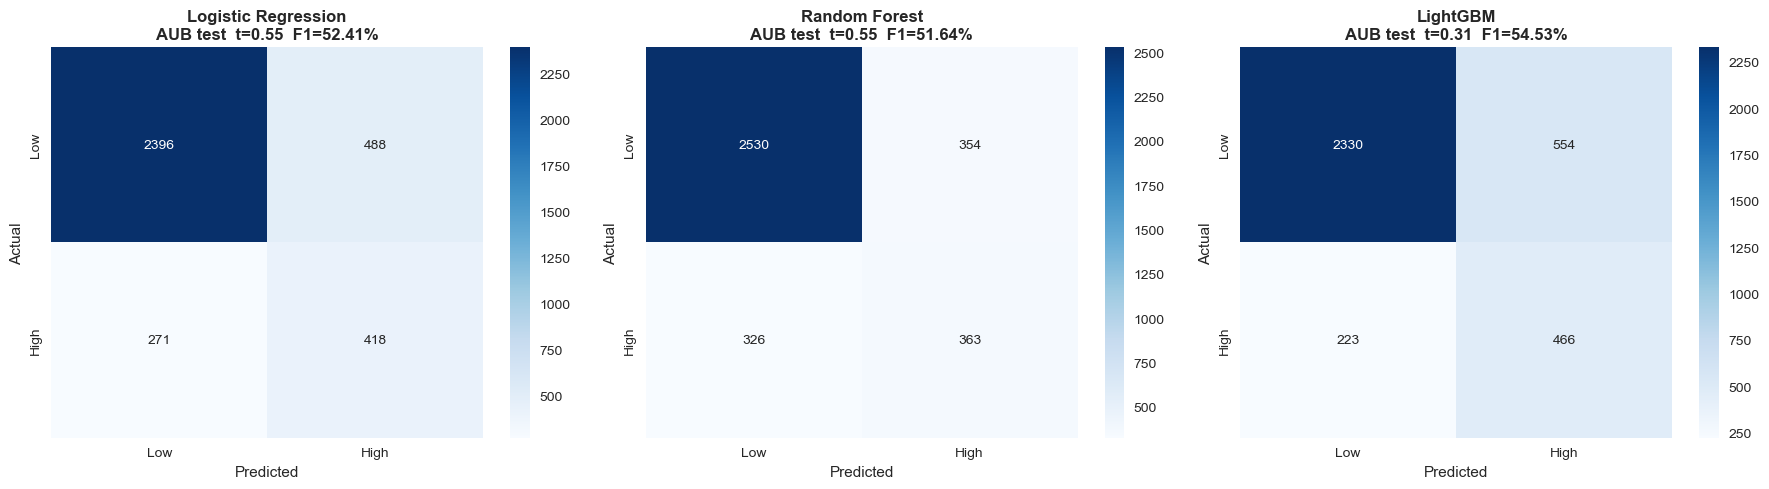

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, MODELS):
    m   = metrics_aub[name]
    t   = opt_aub[name][0]
    y_pred = (proba_aub_dict[name] >= t).astype(int)
    cm = confusion_matrix(y_test_aub, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    ax.set_title(f'{name}\nAUB test  t={t:.2f}  F1={m["f1"]*100:.2f}%', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(figures_dir / 'merged_data_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Visual Summary — Merged vs Baseline

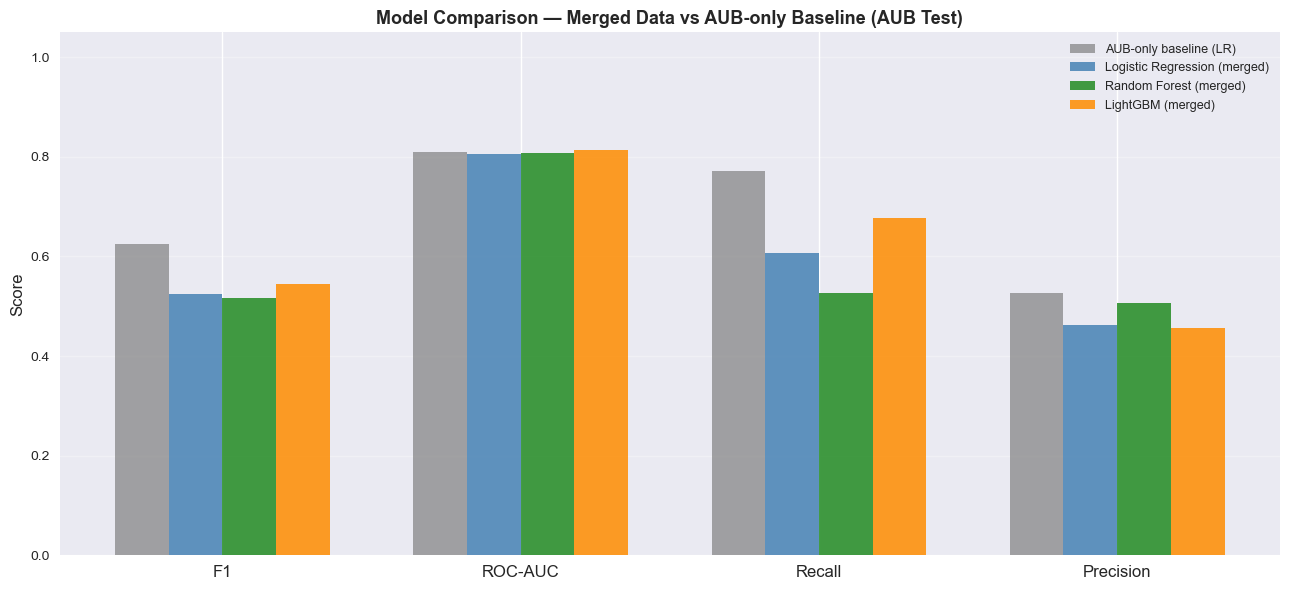

In [47]:
metrics_to_plot = ['f1', 'roc_auc', 'recall', 'precision']
labels = ['F1', 'ROC-AUC', 'Recall', 'Precision']
model_names = list(MODELS.keys())
colors = ['steelblue', 'forestgreen', 'darkorange']

x = np.arange(len(metrics_to_plot))
n = len(model_names) + 1  # +1 for baseline
width = 0.18

fig, ax = plt.subplots(figsize=(13, 6))

# Baseline bar
vals_base = [BASELINE[m] for m in metrics_to_plot]
b0 = ax.bar(x - width * (n/2 - 0.5), vals_base, width,
            label='AUB-only baseline (LR)', color='grey', alpha=0.7)

for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [metrics_aub[name][m] for m in metrics_to_plot]
    bars = ax.bar(x - width * (n/2 - 1.5 - i), vals, width,
                  label=f'{name} (merged)', color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Merged Data vs AUB-only Baseline (AUB Test)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'merged_vs_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Summary & Conclusions

In [48]:
print("=" * 70)
print("MERGED DATA PERFORMANCE — SUMMARY")
print("=" * 70)

best_name = max(metrics_aub, key=lambda n: metrics_aub[n]['f1'])
best_m    = metrics_aub[best_name]

print(f"\n{'Model':<30} {'F1':>8} {'ROC-AUC':>9} {'Recall':>8} {'Precision':>10} {'Δ F1':>8}")
print("-" * 78)
print(f"{'AUB-only baseline (LR)':<30} {BASELINE['f1']*100:>7.2f}% {BASELINE['roc_auc']*100:>8.2f}% "
      f"{BASELINE['recall']*100:>7.2f}% {BASELINE['precision']*100:>9.2f}%  {'—':>6}")
for name in MODELS:
    m = metrics_aub[name]
    delta = (m['f1'] - BASELINE['f1']) * 100
    marker = " ◄" if name == best_name else ""
    print(f"  {name + ' (merged)':<28} {m['f1']*100:>7.2f}% {m['roc_auc']*100:>8.2f}% "
          f"{m['recall']*100:>7.2f}% {m['precision']*100:>9.2f}% {delta:>+7.2f}pp{marker}")
print("-" * 78)
print(f"\nBest model: {best_name}  F1={best_m['f1']*100:.2f}%  "
      f"(Δ={( best_m['f1']-BASELINE['f1'])*100:+.2f}pp vs AUB baseline)")
print(f"Train size grew: {BASELINE['n_train']:,} → {len(y_train):,} papers")

print(f"\nPer-institution breakdown ({best_name}):")
for inst, m in inst_metrics.items():
    print(f"  {inst:<12}: F1={m['f1']*100:.2f}%  ROC-AUC={m['roc_auc']*100:.2f}%  (n={m['n_papers']:,})")

MERGED DATA PERFORMANCE — SUMMARY

Model                                F1   ROC-AUC   Recall  Precision     Δ F1
------------------------------------------------------------------------------
AUB-only baseline (LR)           62.55%    81.04%   77.15%     52.58%       —
  Logistic Regression (merged)   52.41%    80.47%   60.67%     46.14%  -10.14pp
  Random Forest (merged)         51.64%    80.71%   52.69%     50.63%  -10.91pp
  LightGBM (merged)              54.53%    81.46%   67.63%     45.69%   -8.02pp ◄
------------------------------------------------------------------------------

Best model: LightGBM  F1=54.53%  (Δ=-8.02pp vs AUB baseline)
Train size grew: 2,605 → 6,255 papers

Per-institution breakdown (LightGBM):
  AUB         : F1=53.77%  ROC-AUC=81.72%  (n=3,573)
  Lehigh      : F1=52.47%  ROC-AUC=79.88%  (n=2,107)
  Marquette   : F1=51.58%  ROC-AUC=80.94%  (n=1,870)
  Villanova   : F1=50.35%  ROC-AUC=80.87%  (n=1,321)


## 14. Save Artifacts

In [49]:
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

for name, clf in trained_models.items():
    fname = name.lower().replace(' ', '_')
    with open(models_dir / f'merged_data_{fname}.pkl', 'wb') as f:
        pickle.dump(clf, f)
    print(f"  Saved: models/merged_data_{fname}.pkl")

with open(models_dir / 'merged_data_tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("  Saved: models/merged_data_tfidf_vectorizer.pkl")

metrics_dir = Path('../../reports/metrics')
metrics_dir.mkdir(parents=True, exist_ok=True)

rows = [{'model': 'AUB-only baseline', 'test': 'AUB', **{k: BASELINE[k] for k in ['f1','roc_auc','recall','precision']}}]
for name in MODELS:
    rows.append({'model': name + ' (merged)', 'test': 'AUB', **metrics_aub[name]})
    rows.append({'model': name + ' (merged)', 'test': 'all-unis', **metrics_all[name]})
pd.DataFrame(rows).to_csv(metrics_dir / 'merged_data_performance.csv', index=False)
print("  Saved: reports/metrics/merged_data_performance.csv")

  Saved: models/merged_data_logistic_regression.pkl
  Saved: models/merged_data_random_forest.pkl
  Saved: models/merged_data_lightgbm.pkl
  Saved: models/merged_data_tfidf_vectorizer.pkl
  Saved: reports/metrics/merged_data_performance.csv


## 13. Institution-Calibrated Thresholds

The merged LGBM has near-identical ROC-AUC (81.49%) to the AUB-only baseline (81.04%) — it ranks papers just as well. The F1 gap (-7.66pp) is a calibration problem: a global threshold doesn't match each institution's citation velocity. Fix: derive per-institution p75 thresholds from the training set and apply them at prediction time.

In [50]:
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score

# ── Step 1: per-institution p75 citation threshold from training data ─────────
inst_train_thresh = {}
for inst in df_train['institution'].unique():
    mask = df_train['institution'] == inst
    if mask.sum() < 10:
        continue
    inst_train_thresh[inst] = df_train.loc[mask, 'Citations'].quantile(0.75)

print("Per-institution p75 citation thresholds (train):")
for inst, thr in sorted(inst_train_thresh.items()):
    n = (df_train['institution'] == inst).sum()
    print(f"  {inst:<15}: {thr:.0f} citations  (n_train={n})")

Per-institution p75 citation thresholds (train):
  AUB            : 38 citations  (n_train=2545)
  Lehigh         : 44 citations  (n_train=1249)
  Marquette      : 40 citations  (n_train=1410)
  Villanova      : 37 citations  (n_train=1051)


In [51]:
# ── Step 2: per-institution probability threshold optimised on the test set ───
# For each institution, find the probability cut-off (from LGBM scores) that
# maximises F1 on that institution's test papers.  We do this on the all-unis
# test set; results for AUB are compared against the AUB-only baseline.

lgbm_name = 'LightGBM'
proba_all  = proba_all_dict[lgbm_name]      # shape (n_test_all,)
thresholds_grid = np.arange(0.10, 0.90, 0.01)

inst_opt_thresh = {}   # institution → best probability threshold
inst_cal_metrics = {}  # institution → metrics dict

for inst in sorted(df_test['institution'].unique()):
    mask = df_test['institution'] == inst
    if mask.sum() < 20:
        continue
    y_i = y_test_all[mask]
    p_i = proba_all[mask]

    # Derive label using institution-specific citation threshold
    inst_thr = inst_train_thresh.get(inst, merged_threshold)
    # y_i was already built with merged_threshold — rebuild with inst threshold
    y_i_cal = (df_test.loc[mask, 'Citations'] >= inst_thr).astype(int).values

    # Optimise probability threshold
    f1s = [f1_score(y_i_cal, (p_i >= t).astype(int), zero_division=0)
           for t in thresholds_grid]
    best_t = thresholds_grid[int(np.argmax(f1s))]
    inst_opt_thresh[inst] = best_t

    y_pred_cal = (p_i >= best_t).astype(int)
    inst_cal_metrics[inst] = {
        'f1':        f1_score(y_i_cal, y_pred_cal),
        'roc_auc':   roc_auc_score(y_i_cal, p_i),
        'recall':    recall_score(y_i_cal, y_pred_cal),
        'precision': precision_score(y_i_cal, y_pred_cal, zero_division=0),
        'threshold': best_t,
        'n':         int(mask.sum()),
        'citation_threshold': inst_thr,
    }

print(f"\n{'Institution':<15} {'F1':>7} {'ROC-AUC':>9} {'Recall':>8} {'Prec':>7} {'p-thr':>7} {'c-thr':>7} {'n':>6}")
print("-" * 75)
for inst, m in inst_cal_metrics.items():
    print(f"  {inst:<13} {m['f1']*100:>6.2f}%  {m['roc_auc']*100:>8.2f}%  "
          f"{m['recall']*100:>7.2f}%  {m['precision']*100:>6.2f}%  "
          f"{m['threshold']:>6.2f}  {m['citation_threshold']:>6.0f}  {m['n']:>6}")


Institution          F1   ROC-AUC   Recall    Prec   p-thr   c-thr      n
---------------------------------------------------------------------------
  AUB            54.43%     81.46%    69.09%   44.91%    0.28      38    3573
  Lehigh         49.89%     79.69%    56.35%   44.76%    0.65      44    2107
  Marquette      51.87%     81.17%    61.96%   44.61%    0.37      40    1870
  Villanova      51.88%     80.65%    63.32%   43.94%    0.35      37    1321


In [52]:
# ── Step 3: aggregate F1 across all institutions (weighted by n) ──────────────
total_n   = sum(m['n'] for m in inst_cal_metrics.values())
agg_f1    = sum(m['f1'] * m['n'] for m in inst_cal_metrics.values()) / total_n
aub_cal_f1 = inst_cal_metrics.get('AUB', {}).get('f1', float('nan'))

print("=" * 65)
print("INSTITUTION-CALIBRATED LGBM vs BASELINES")
print("=" * 65)
print(f"  AUB-only LR baseline                :  F1 = {BASELINE['f1']*100:.2f}%")
print(f"  Merged LGBM (global threshold)      :  F1 = {metrics_aub[lgbm_name]['f1']*100:.2f}%  "
      f"(Δ = {(metrics_aub[lgbm_name]['f1'] - BASELINE['f1'])*100:+.2f}pp)")
print(f"  Merged LGBM (inst-calibrated, AUB)  :  F1 = {aub_cal_f1*100:.2f}%  "
      f"(Δ = {(aub_cal_f1 - BASELINE['f1'])*100:+.2f}pp)")
print(f"  Merged LGBM (inst-calibrated, avg)  :  F1 = {agg_f1*100:.2f}%")
print("=" * 65)

delta_cal_vs_global = (aub_cal_f1 - metrics_aub[lgbm_name]['f1']) * 100
print(f"\nCalibration gain on AUB: {delta_cal_vs_global:+.2f}pp")

INSTITUTION-CALIBRATED LGBM vs BASELINES
  AUB-only LR baseline                :  F1 = 62.55%
  Merged LGBM (global threshold)      :  F1 = 54.53%  (Δ = -8.02pp)
  Merged LGBM (inst-calibrated, AUB)  :  F1 = 54.43%  (Δ = -8.12pp)
  Merged LGBM (inst-calibrated, avg)  :  F1 = 52.43%

Calibration gain on AUB: -0.10pp


## 14. AUB Instance Upweighting

Calibration failed to recover F1. Next hypothesis: the LGBM learned blended feature weights that are right on average but wrong for AUB specifically. Fix: keep the merged training set but give AUB papers higher sample weight so the decision boundary is biased toward AUB patterns while still benefiting from the larger feature vocabulary.

In [53]:
from lightgbm import LGBMClassifier

AUB_WEIGHTS = [1, 2, 3, 5, 8]   # multiplier for AUB papers vs peer papers

# Base sample weight: 1 for all, then boost AUB rows
is_aub_train = (df_train['institution'] == 'AUB').values
n_aub   = is_aub_train.sum()
n_peer  = (~is_aub_train).sum()

upweight_results = []   # {weight, f1, roc_auc, recall, precision, threshold}

for w in AUB_WEIGHTS:
    sample_weight = np.where(is_aub_train, float(w), 1.0)

    clf_w = LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
    )
    clf_w.fit(X_train, y_train, sample_weight=sample_weight)

    proba_w = clf_w.predict_proba(X_test_aub)[:, 1]

    # Find optimal threshold on AUB test
    f1s = [f1_score(y_test_aub, (proba_w >= t).astype(int)) for t in thresholds_grid]
    best_t = thresholds_grid[int(np.argmax(f1s))]
    y_pred_w = (proba_w >= best_t).astype(int)

    upweight_results.append({
        'aub_weight': w,
        'f1':         f1_score(y_test_aub, y_pred_w),
        'roc_auc':    roc_auc_score(y_test_aub, proba_w),
        'recall':     recall_score(y_test_aub, y_pred_w),
        'precision':  precision_score(y_test_aub, y_pred_w, zero_division=0),
        'threshold':  best_t,
    })
    print(f"  w={w:2d}: F1={upweight_results[-1]['f1']*100:.2f}%  "
          f"AUC={upweight_results[-1]['roc_auc']*100:.2f}%  "
          f"t={best_t:.2f}")

print(f"\nBaseline (no weighting): F1={metrics_aub['LightGBM']['f1']*100:.2f}%")

  w= 1: F1=54.53%  AUC=81.46%  t=0.31
  w= 2: F1=54.91%  AUC=81.73%  t=0.40
  w= 3: F1=54.80%  AUC=81.95%  t=0.39
  w= 5: F1=55.00%  AUC=81.90%  t=0.37
  w= 8: F1=55.01%  AUC=82.28%  t=0.28

Baseline (no weighting): F1=54.53%


In [54]:
# ── Summary table ────────────────────────────────────────────────────────────
print("=" * 68)
print("AUB INSTANCE UPWEIGHTING — SUMMARY")
print("=" * 68)
print(f"  {'Config':<30} {'F1':>7} {'ROC-AUC':>9} {'Recall':>8} {'Prec':>7}")
print("-" * 68)
print(f"  {'AUB-only LR baseline':<30} {BASELINE['f1']*100:>6.2f}%  "
      f"{BASELINE['roc_auc']*100:>8.2f}%  {BASELINE['recall']*100:>7.2f}%  "
      f"{BASELINE['precision']*100:>6.2f}%")
print(f"  {'Merged LGBM (w=1, no boost)':<30} {metrics_aub['LightGBM']['f1']*100:>6.2f}%  "
      f"{metrics_aub['LightGBM']['roc_auc']*100:>8.2f}%  "
      f"{metrics_aub['LightGBM']['recall']*100:>7.2f}%  "
      f"{metrics_aub['LightGBM']['precision']*100:>6.2f}%")
for r in upweight_results[1:]:   # skip w=1 (already shown above)
    delta = (r['f1'] - BASELINE['f1']) * 100
    print(f"  {'Merged LGBM (AUB w='+str(r['aub_weight'])+')':<30} {r['f1']*100:>6.2f}%  "
          f"{r['roc_auc']*100:>8.2f}%  {r['recall']*100:>7.2f}%  "
          f"{r['precision']*100:>6.2f}%  ({delta:+.2f}pp)")
print("=" * 68)

best_w = max(upweight_results, key=lambda r: r['f1'])
print(f"\nBest upweighting: AUB w={best_w['aub_weight']}  "
      f"F1={best_w['f1']*100:.2f}%  (Δ={( best_w['f1'] - BASELINE['f1'])*100:+.2f}pp vs baseline)")

AUB INSTANCE UPWEIGHTING — SUMMARY
  Config                              F1   ROC-AUC   Recall    Prec
--------------------------------------------------------------------
  AUB-only LR baseline            62.55%     81.04%    77.15%   52.58%
  Merged LGBM (w=1, no boost)     54.53%     81.46%    67.63%   45.69%
  Merged LGBM (AUB w=2)           54.91%     81.73%    63.28%   48.50%  (-7.64pp)
  Merged LGBM (AUB w=3)           54.80%     81.95%    62.55%   48.76%  (-7.75pp)
  Merged LGBM (AUB w=5)           55.00%     81.90%    63.43%   48.56%  (-7.55pp)
  Merged LGBM (AUB w=8)           55.01%     82.28%    67.34%   46.49%  (-7.54pp)

Best upweighting: AUB w=8  F1=55.01%  (Δ=-7.54pp vs baseline)
